In [42]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [43]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [44]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [45]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.
    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [46]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start
    
    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state == self.goal
    
    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0
    
    def actions(self, state: Tuple[int, int]) -> List[str]:
        #TODO 2 :Return a list of legal action names.
        legal_actions = []
        row, col = state
        for action, (r,c) in MOVES.items():
            neighbour_cell = (row + r, col + c)
            if self.in_bounds(neighbour_cell) and self.is_free (neighbour_cell):
                    legal_actions.append(action)
        return legal_actions
    
    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3: Return the next state after applying action to state.
         row, col = state
         dr, dc = MOVES[action]
         return (row + dr, col + dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        #TODO 4
        return 1    


In [47]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [48]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

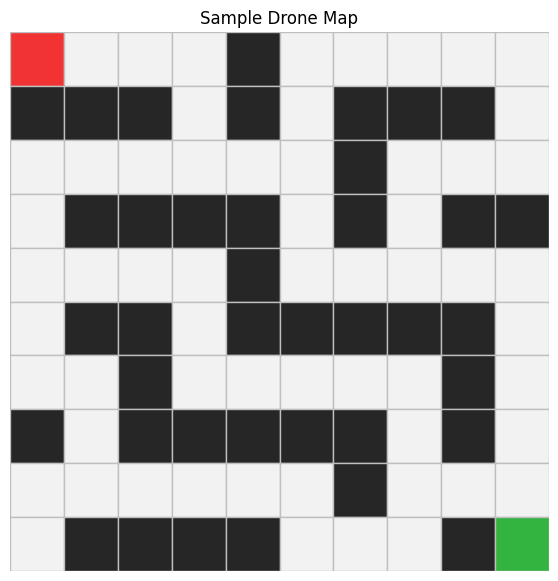

In [49]:

def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [50]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5: Implement the AIMA-style EXPAND(problem, node).
        s = node.state
        # for each action in problem.ACTIONS(s):
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(state=s_prime, parent=node, 
                       action=action, path_cost=cost)
    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [51]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"
        nodes_expanded = 0
        max_frontier_size = 0

        node = Node(state=problem.initial_state())

        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=nodes_expanded,
                max_frontier_size=max_frontier_size,
                reached_count=1,
            )

        frontier = deque([node])
        reached = {problem.initial_state()}

        while frontier:
            node = frontier.popleft()  #poping from front
            nodes_expanded += 1

            for child in self.expand(problem, node):
                s = child.state

                if problem.is_goal(s):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached),
                    )

                if s not in reached:
                    reached.add(s)
                    frontier.append(child)

            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )


In [52]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"
        nodes_expanded = 0
        max_frontier_size = 0

        # node ← NODE(problem.INITIAL)
        node = Node(state=problem.initial_state())

        # if problem.IS-GOAL(node.STATE) then return node
        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=nodes_expanded,
                max_frontier_size=max_frontier_size,
                reached_count=1,
            )

        # frontier ← a LIFO stack with node as an element
        frontier = [node]

        # reached ← {problem.INITIAL}
        reached = {problem.initial_state()}

        # while frontier is not empty do
        while frontier:

            # node ← POP(frontier)
            node = frontier.pop()
            nodes_expanded += 1

            # for each child in EXPAND(problem, node) do
            for child in self.expand(problem, node):
                s = child.state

                # if problem.IS-GOAL(s) then return child
                if problem.is_goal(s):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached),
                    )

                # if s is not in reached
                if s not in reached:
                    reached.add(s)
                    frontier.append(child)

            # update max_frontier_size
            max_frontier_size = max(max_frontier_size, len(frontier))

        # return failure
        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )


In [53]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:

        # If node.state is goal, return (node, "success")
        if problem.is_goal(node.state):
            return (node, "success")

        # Else if node.depth >= limit, return (None, "cutoff")
        elif node.depth >= limit:
            return (None, "cutoff")

        # Otherwise
        else:
            # increment nodes_expanded
            metrics["nodes_expanded"] += 1

            # set cutoff_occurred = False
            cutoff_occurred = False

            # for each child in expand(problem, node)
            for child in self.expand(problem, node):

                # skip if child.state already on current path
                if state_is_on_path(node, child.state):
                    continue

                # update max_stack_size
                current_stack_size += 1
                if current_stack_size > metrics["max_stack_size"]:
                    metrics["max_stack_size"] = current_stack_size

                # recursively call _recursive_dls on child
                result, status = self._recursive_dls(
                    problem=problem,
                    node=child,
                    limit=limit,
                    metrics=metrics,
                    current_stack_size=current_stack_size,
                )

                #if success, return immediately
                if status == "success":
                    return (result, "success")

                # if cutoff, remember it
                elif status == "cutoff":
                    cutoff_occurred = True

                current_stack_size -= 1

            #after all children
            if cutoff_occurred:
                return (None, "cutoff")
            else:
                return (None, "failure")


In [54]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        #Keep a list called iteration_log
        iteration_log = []

        #Accumulate total nodes expanded
        nodes_expanded = 0

        #Track maximum stack size
        max_frontier_size = 0

        # create DLS object to reuse
        dls = DepthLimitedSearch()

        # loop from limit 0 to max_depth
        for limit in range(max_depth + 1):

            # call DLS with current limit
            result = dls.search(problem, limit=limit)

            # accumulate nodes expanded
            nodes_expanded += result.nodes_expanded

            # rack max stack size
            max_frontier_size = max(max_frontier_size, result.max_frontier_size)

            # record this iteration in the log
            iteration_log.append({
                "limit": limit,
                "status": result.status,
                "nodes_expanded": result.nodes_expanded,
            })

            #  if success, return immediately
            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=result.solution,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    reached_count=0,
                    limit=limit,
                    iterations=iteration_log,
                )

            #if failure, stop early
            elif result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    reached_count=0,
                    limit=limit,
                    iterations=iteration_log,
                )

        #all limits returned cutoff
        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=0,
            limit=max_depth,
            iterations=iteration_log,
        )

In [55]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=20),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18,18,50,5,52
1,DFS,success,NaN,18,18,18,4,21
2,DLS,success,20.0,18,18,63,21,0
3,IDS,success,18.0,18,18,356,19,0


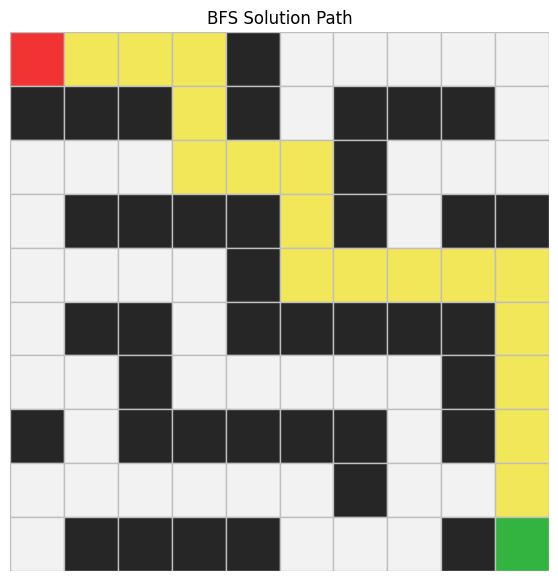

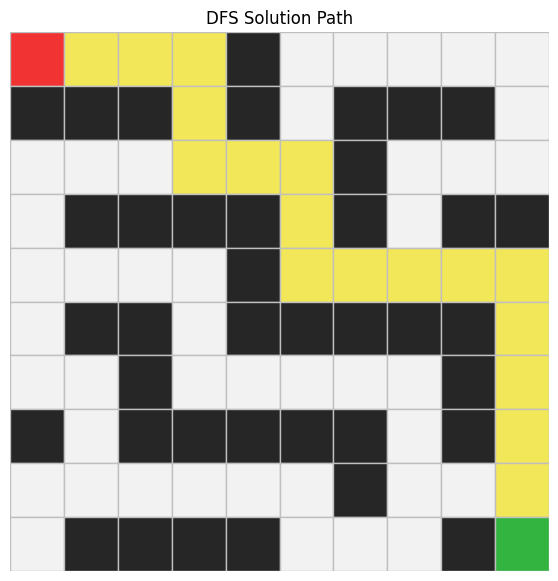

In [56]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

In [57]:
# TODO 10: Custom Map 1 - maze like environment

custom_grid_1 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1, 1, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 0, 0, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

custom_start_1 = (0, 0)
custom_goal_1 = (9, 9)

custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=30),
    ids.search(custom_problem_1, max_depth=50),
]
show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18,18,35,3,37
1,DFS,success,NaN,18,18,18,2,19
2,DLS,success,30.0,18,18,31,31,0
3,IDS,success,18.0,18,18,308,19,0


In [58]:
# TODO 10: Custom Map 2 - Many Dead Ends (15x15)
custom_grid_2 = [
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0],
    [0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
]

custom_start_2 = (0, 0)
custom_goal_2 = (14, 14)

custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=35),
    ids.search(custom_problem_2, max_depth=60),
]
show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,32,32,88,5,89
1,DFS,success,NaN,32,32,128,7,130
2,DLS,success,35.0,32,32,55,36,0
3,IDS,success,32.0,32,32,1212,33,0


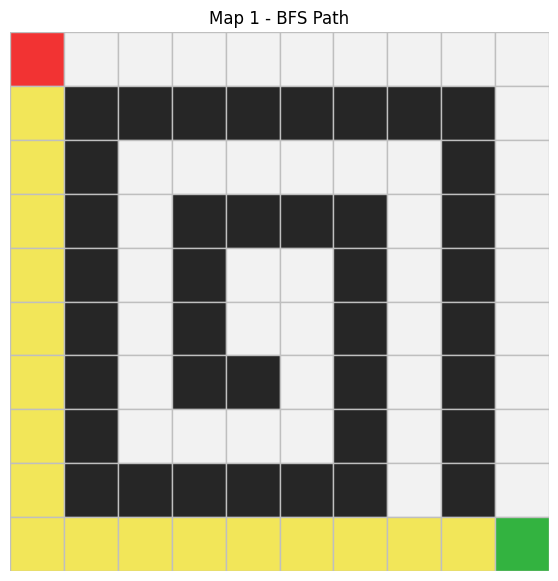

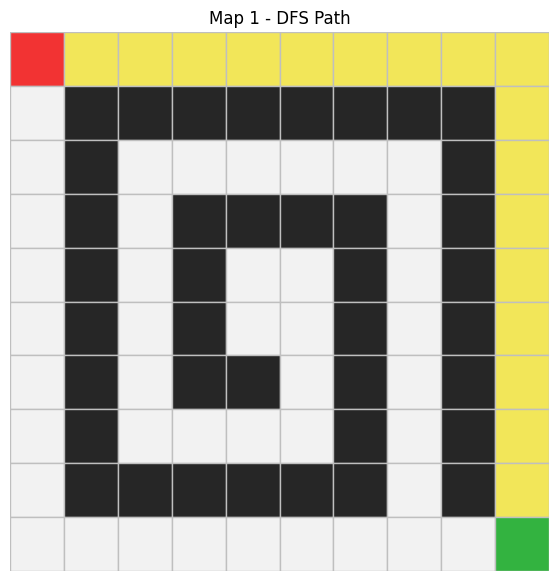

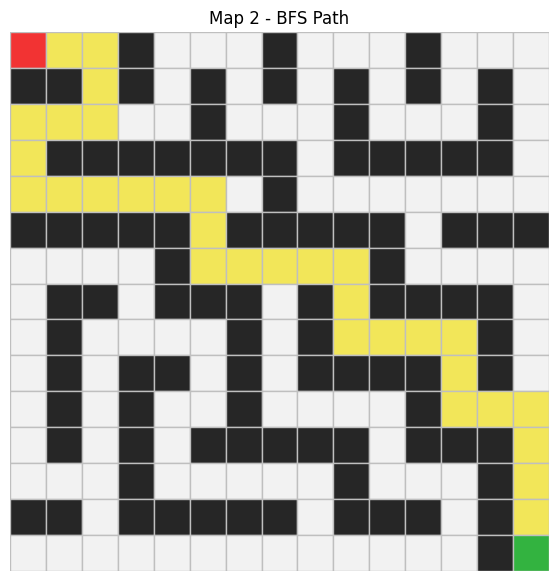

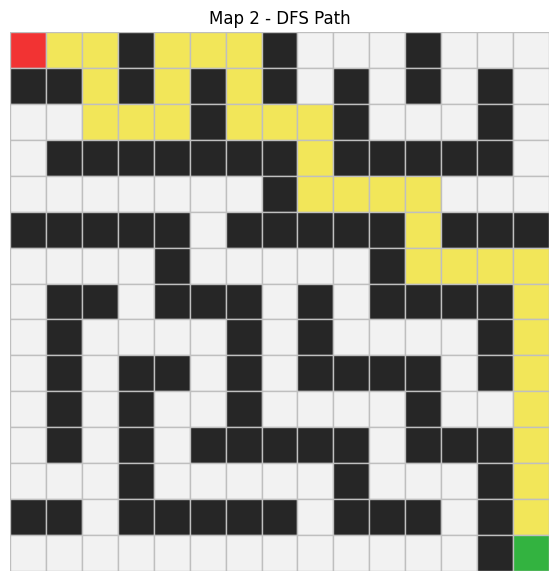

In [59]:
# Visualize Map 1
plot_path(custom_grid_1, custom_start_1, custom_goal_1,
          path=custom_results_1[0].path, title="Map 1 - BFS Path")
plot_path(custom_grid_1, custom_start_1, custom_goal_1,
          path=custom_results_1[1].path, title="Map 1 - DFS Path")

# Visualize Map 2
plot_path(custom_grid_2, custom_start_2, custom_goal_2,
          path=custom_results_2[0].path, title="Map 2 - BFS Path")
plot_path(custom_grid_2, custom_start_2, custom_goal_2,
          path=custom_results_2[1].path, title="Map 2 - DFS Path")

## 15.1:    Problem Formulation
## 1: What is a state in this lab?
A state is the drone's current position on the grid, which is represented as a tuple (row, col). For example, (0, 0) means the drone is at row 0, column 0. A state is just raw data describing where the drone is, nothing more at a particular instance. 

## 2: What is an Action?
An action is a direction the drone can move either: "UP", "DOWN", "LEFT", or "RIGHT". in ur case, not every action is legal from every state. The actions(state) method filters out moves that would take the drone off the grid or into an obstacle Only moves where the neighbour cell is both in bounds AND free are returned as legal actions.

## 3: What does the result function do?
The result(state, action) method computes where the drone ends up after taking an action. it adds the direction info in the MOVES dict to the current (row, col). 

## 4: Why is it useful to separate the problem definition from the search algorithm?
Separating the problem definition from the search algorithm makes the code both easy to use and highly reusable.
The same BFS, DFS, DLS, and IDS classes worked across all three maps without changing a single line of code. it was implemented by simply creating a new GridProblem object for each map and passed it in. This means if we ever needed to solve a completely different problem (a road network, a puzzle), we would just write a new Problem subclass implementing the five methods and all four algorithms would work on it immediately, with no modifications needed.


## 15. 2: BFS

## 1: Why does BFS use a FIFO queue?
BFS uses a FIFO queue so nodes get explored in the same order they're discovered. Adding to the back and popping from the front ensures
everything at the current depth gets checked before anything at the next depth.

## 2: Why does BFS find the shortest path in terms of number of steps on the unweighted grid?
BFS finds the shortest path because it explores nodes level by level.Since every move costs the same( 1  in this case) , the first time BFS reaches the goal it must be via the fewest possible steps, a shorter path would hsve already been found at an earlier level.

## 3 : What role does the reached set play in BFS?
reached stops BFS from doing redundant work by keeping track of every state it has already visited. without it the search could keep re-checking states it has already been to, in the worst case bouncing back and forth between states forever and never finishing. by checking a state against reached before adding it to the frontier, BFS makes sure each state only gets processed once.

## 15.3 : DFS

## 1: Why does DFS use a stack?
DFS uses a stack so the most recently added node gets explored next instead of the oldest one. adding to the back and popping from the back with frontier.pop() means it keeps diving into whatever path it just opened up instead of going wide.

## 2: Is DFS guaranteed to find the shortest path? Explain.
No, it  just commits to the first path it finds since it dives deep without checking other options first, so it has no way of knowing if a shorter path exists elsewhere. on our maps DFS sometimes matched BFS's depth by chance but on the 15x15 dead ends map it ended up expanding more nodes than BFS because it kept on going down wrong branches before backtracking.


## 3: Under what conditions can DFS use less memory than BFS?
it uses less memory when the goal is deep in the tree, like at the last level, since it only keeps the current path in memory instead of every node at the current depth like BFS does.

## 4: Under what conditions can DFS perform badly?
DFS performs badly when the search space has a lot of dead ends or long branches that don't lead anywhere, since it'll fully explore those before backtracking and trying something else. it can also perform badly on very deep or unbounded spaces since nothing stops it from just going deeper and deeper without ever finding the goal.


## 15.4: DLS

## 1: What happens when the depth limit is too small?
it returns a cutoff status, meaning it hit the limit before reaching the goal. it doesn't mean there is no solution, just that it might be deeper than what DLS was allowed to check.  

## 2: What is the meaning of cutoff
cutoff means the search ran out of depth before confirming success or failure. itis different from failure, failure means there is genuinely no solution within what was explored, cutoff just means it stopped too early and the answer could still exist deeper.

## 3: How is DLS different from ordinary DFS?
DLS is DFS with a constraint on how deep it can go. normal DFS keeps going with nothing to stop it, DLS checks node.depth >= limit and stops once it hits that.

## 4: Why do we use path-cycle checking in DLS?
because a global reached set would permanently block a state once visited, but DLS might legitimately need to reach that same state again through a different, possibly better path later on. path-cycle checking only stops a state from repeating within the current path being explored, so it prevents loops without ruling out other valid routes to that state.



## 15.5: IDS

## 1: Why does IDS repeat DLS with increasing limits?
because we don't know upfront how deep the solution is. starting at limit 0 and going up by 1 each round guarantees IDS eventually hits the exact depth where the solution sits, without wasting memory searching deeper than necessary too early.

## 2: Why can IDS be complete even though DLS with a small limit is not?
a fixed small limit on DLS just cannot reach anything past that depth, so itis incomplete by design. IDS keeps raising the limit until it finds the solution or proves that there is none, so it never permanently gives up.

## 3: Why does IDS use less memory than BFS?
because each DLS run inside IDS only keeps the current path in memory like DFS does, while BFS keeps the whole frontier at the current depth which grows wide fast.

## 4: What is the cost of repeatedly searching from the root? 
it reexpands all the shallow nodes again at every single limit increase. the deeper the actual solution is, the worse this gets since every round means redoing the same shallow work from scratch, that's the price IDS pays for staying memory efficient and still complete.


## 15.6  : Real-World Drone Context
## 1: In a real drone application, what might make one route safer or more practical than another?
The things like weather and wind conditions, no-fly zones that can show up temporarily, battery level limiting how far a detour the drone can actually afford, and signal strength so it does not  fly somewhere it loses GPS or control. in our case, our grid only knows a cell is blocked or free, it doesn account for any of this.

## 2: Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves? Explain.
BFS, since it is  guaranteed to find the path with the fewest steps when every move costs the same. it uses more memory than DFS but if step count is all that matters that tradeoff is worth it.

## 3: Which algorithm would you choose if you want to limit how deep the drone is allowed to search? Explain.
DLS, since it has a depth limit built in so you can cap exactly how far the drone searches before giving up. if you donnot know the right limit ahead of time, IDS is better since it raises the limit automatically until it finds the goal.

## 4: What limitations does this grid model have compared with real drone navigation?
the grid only allows 4 directions and treats cells as either fully open or fully blocked(0 or 1), real flight has way more freedom of movement and terrain varies in difficulty instead of just blocked or free. it also assumes a static map with no moving obstacles, no changing weather, and no battery constraints, and assumes the drone always knows its exact position and the full map upfront.




